In [1]:
import tensorflow as tf
from tensorflow.keras import layers , models
print(tf.config.list_physical_devices('GPU'))

import numpy as np
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

I0000 00:00:1787918715.382920    4846 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787918715.419333    4846 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787918717.084049    4846 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# prepare image

In [2]:
# download & Extract file
url='https://github.com/brendenlake/omniglot/raw/master/python/images_background.zip'
path_to_zip=tf.keras.utils.get_file('images_background.zip' , origin=url , extract=True)

In [3]:
# Walk through the dataset directory to finding image paths and their corresponding labels (folder names)
def get_img_path_labels(base_dir):
    img_path=[]
    labels=[]
    for root , dirs , files in os.walk(base_dir):
        for file in files:
            if file.endswith('.png') or file.endswith('.jpg'):
                img_path.append(os.path.join(root , file))
                labels.append(root.split('/')[-2])

    return img_path , labels

base_dir='/home/ziba/.keras/datasets/images_background_extracted/images_background'
img_path , labels=get_img_path_labels(base_dir)
print(f'total images : {len(img_path)}  , total labels:{len(set(labels))}')

print(f'image_path_1: {img_path[0]}')
print(f'label_img_1: {labels[0]}')

total images : 19280  , total labels:30
image_path_1: /home/ziba/.keras/datasets/images_background_extracted/images_background/Cyrillic/character09/0226_03.png
label_img_1: Cyrillic


## class-level split

In [4]:
print(np.unique(labels))
label_encoder=LabelEncoder()
labels=label_encoder.fit_transform(labels)

uniqe_class=np.unique(labels)
print("Encoded labels:",uniqe_class)
print("Number of classes:", len(np.unique(labels)))

print(type(uniqe_class))
print(uniqe_class.shape)
print(uniqe_class.dtype)


['Alphabet_of_the_Magi' 'Anglo-Saxon_Futhorc' 'Arcadian' 'Armenian'
 'Asomtavruli_(Georgian)' 'Balinese' 'Bengali'
 'Blackfoot_(Canadian_Aboriginal_Syllabics)' 'Braille' 'Burmese_(Myanmar)'
 'Cyrillic' 'Early_Aramaic' 'Futurama' 'Grantha' 'Greek' 'Gujarati'
 'Hebrew' 'Inuktitut_(Canadian_Aboriginal_Syllabics)'
 'Japanese_(hiragana)' 'Japanese_(katakana)' 'Korean' 'Latin'
 'Malay_(Jawi_-_Arabic)' 'Mkhedruli_(Georgian)' 'N_Ko'
 'Ojibwe_(Canadian_Aboriginal_Syllabics)' 'Sanskrit' 'Syriac_(Estrangelo)'
 'Tagalog' 'Tifinagh']
Encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
Number of classes: 30
<class 'numpy.ndarray'>
(30,)
int64


In [5]:
train_classes, test_classes = train_test_split(uniqe_class,test_size=0.2,random_state=42)

print("Train classes:", len(train_classes))
print("Test classes :", len(test_classes))
print(type(train_classes))
print(type(test_classes))

Train classes: 24
Test classes : 6
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [6]:
print("Overlap:", np.intersect1d(train_classes, test_classes))

Overlap: []


In [7]:
# Create boolean masks to separate training and test classes
# train_mask: True for samples belonging to train_classes
# test_mask: True for samples belonging to test_classes
train_mask = np.isin(labels, train_classes)
test_mask = np.isin(labels, test_classes)

# Print mask sizes (should equal total number of samples)
print("train_mask:", len(train_mask))
print("test_mask :", len(test_mask))

# Verify masks contain boolean values and have both True/False
print("train_mask unique values:", np.unique(train_mask))
print("test_mask unique values:", np.unique(test_mask))

train_mask: 19280
test_mask : 19280
train_mask unique values: [False  True]
test_mask unique values: [False  True]


In [8]:
# Filtering Data Using Boolean Masks

# Convert img_path & labels to numpy array and apply train_mask to get training image paths & labels
train_path = np.asarray(img_path)[train_mask]
train_label = np.asarray(labels)[train_mask]

# Apply test_mask to get test image paths & labels
test_path = np.asarray(img_path)[test_mask]
test_label = np.asarray(labels)[test_mask]

In [9]:
print("train_path:", len(train_path))
print("train_label:", len(train_label))

print("test_path:", len(test_path))
print("test_label:", len(test_label))

train_path: 15520
train_label: 15520
test_path: 3760
test_label: 3760


In [10]:
overlap = np.intersect1d(np.unique(train_label), np.unique(test_label))
print("Class overlap:", overlap)

Class overlap: []


In [11]:
img_size=224
embedding_DIM = 256
batch_size=8
epochs=7

In [12]:
# Load and preprocess a single image: read, decode, resize
def load_img(img_path,labels):
    
    img=tf.io.read_file(img_path)
    img=tf.image.decode_png(img , channels=3)
    img=tf.image.resize(img , (img_size,img_size))
    img = tf.keras.applications.resnet50.preprocess_input(img)

    return img , labels

In [13]:
# Generate infinite triplets: (anchor, positive/negative, label) where 1=same class, 0=different class
def pair_generator(img_paths, labels):

    labels =(labels).reshape(-1)
    unique_labels = np.unique(labels)
    class_to_indices = {label: np.where(labels == label)[0]for label in unique_labels}

    while True:

        # select anchor
        idx = np.random.randint(len(img_paths))

        anchor_path = img_paths[idx]
        anchor_label = labels[idx]

        # Positive pair
        positive_indices = class_to_indices[anchor_label]
        positive_idx = np.random.choice(positive_indices)
        positive_path = img_paths[positive_idx]

        yield anchor_path, positive_path, 1

        # Negative pair
        negative_label =unique_labels[ unique_labels !=anchor_label ]
        negative_label=np.random.choice(negative_label)
        negative_indices = class_to_indices[ negative_label]
        negative_idx = np.random.choice(negative_indices)
        negative_path = img_paths[negative_idx]

        yield anchor_path, negative_path, 0

# Convert the Python generator into a tf.data pipeline for efficient positive and negative pair generation
train_pair_ds = tf.data.Dataset.from_generator(lambda: pair_generator(train_path, train_label),
                                         output_signature=(tf.TensorSpec(shape=(), dtype=tf.string),
                                                           tf.TensorSpec(shape=(), dtype=tf.string),
                                                           tf.TensorSpec(shape=(), dtype=tf.int32)))

test_pair_ds = tf.data.Dataset.from_generator(lambda: pair_generator(test_path, test_label),
                                         output_signature=(tf.TensorSpec(shape=(), dtype=tf.string),
                                                           tf.TensorSpec(shape=(), dtype=tf.string),
                                                           tf.TensorSpec(shape=(), dtype=tf.int32)))
# Load and preprocess a pair of images (anchor & positive/negative) without retaining their original labels
def load_pair(path1, path2, pair_label):
    img1,_ = load_img(path1,labels)
    img2, _ = load_img(path2, labels)

    return (img1, img2), tf.cast(pair_label,tf.float32)

# Apply the pair loading function to the dataset, processing image pairs in parallel for faster performance
train_pair_ds = train_pair_ds.map(load_pair,num_parallel_calls=tf.data.AUTOTUNE)
test_pair_ds = test_pair_ds.map(load_pair,num_parallel_calls=tf.data.AUTOTUNE)

I0000 00:00:1787918720.169277    4846 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [14]:
#  Batch + Prefetch
train_pair_ds=train_pair_ds.batch(batch_size)
train_pair_ds=train_pair_ds.prefetch(tf.data.AUTOTUNE)

test_pair_ds=test_pair_ds.batch(batch_size)
test_pair_ds=test_pair_ds.prefetch(tf.data.AUTOTUNE)

# load resnet50 model & fit model

In [15]:
# Create ResNet50 Encoder
base_model=tf.keras.applications.ResNet50(weights='imagenet' , include_top=False, input_shape=(img_size,img_size,3), pooling='avg')

# Freeze ResNet50
base_model.trainable=False

In [16]:
#Create embedding network
inputs=layers.Input(shape=(img_size,img_size,3)) 

x=base_model(inputs , training=False)
x=layers.Dense(embedding_DIM)(x)
x=layers.BatchNormalization()(x)
x=layers.ReLU()(x)
x=layers.Lambda(lambda x : tf.math.l2_normalize(x, axis=1))(x)

encoder=models.Model(inputs , x , name='ResNet50_Encoder')
encoder.summary()

Model: "ResNet50_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,280 (91.98 MB)

 Trainable params: 525,056 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [17]:
#Siamese Network
input_1=layers.Input(shape=(img_size,img_size,3) , name='image_1')
input_2=layers.Input(shape=(img_size,img_size,3) , name='image_2')

embedding_1=encoder(input_1)
embedding_2=encoder(input_2)

In [18]:
#Euclidean distance
distance = layers.Lambda(lambda tensors: tf.sqrt(tf.reduce_sum(tf.square(tensors[0] - tensors[1]),axis=1,keepdims=True) + 1e-8))([embedding_1, embedding_2])

siamese_model=models.Model(inputs=[input_1,input_2] , outputs=distance , name='Siamese_ResNet50')

siamese_model.summary()

Model: "Siamese_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_1             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_2             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ResNet50_Encoder    │ (None, 256)       │ 24,113,280 │ image_1[0][0],    │
│ (Functional)        │                   │            │ image_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ ResNet50_Encoder… │
│                     │                   │            │ ResNet50_Encoder… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,280 (91.98 MB)

 Trainable params: 525,056 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [19]:
#Contrastive Loss

def contrastive_loss(y_true , y_pred , margin=1.0):
    y_true=tf.cast(y_true , tf.float32)
    y_true=tf.reshape(y_true , (-1,1))

    posetive_loss=y_true * tf.square(y_pred)
    negative_loss=(1-y_true) * tf.square(tf.maximum(margin-y_pred , 0))

    loss=posetive_loss+negative_loss

    return tf.reduce_mean(loss)


In [20]:
# Compile
siamese_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),loss=contrastive_loss )

In [21]:
# train
history=siamese_model.fit(train_pair_ds , steps_per_epoch=500 , epochs=epochs, validation_data=test_pair_ds , validation_steps=100)

Epoch 1/7


I0000 00:00:1787918721.971584    4846 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1787918726.379713    4948 service.cc:153] XLA service 0x7c51c0034e10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787918726.379740    4948 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787918726.613473    4948 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787918728.280752    4948 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787918728.335332    4948 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18201__.360


  1/500 ━━━━━━━━━━━━━━━━━━━━ 1:54:41 14s/step - loss: 0.5615

I0000 00:00:1787918735.605357    4948 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.5017

I0000 00:00:1787918760.554673    4946 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_23828__.11
I0000 00:00:1787918761.744011    4946 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'fusion_553', 4 bytes spill stores, 4 bytes spill loads



500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 62ms/step - loss: 0.4593 - val_loss: 0.3325
Epoch 2/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - loss: 0.3752 - val_loss: 0.2936
Epoch 3/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - loss: 0.3124 - val_loss: 0.2737
Epoch 4/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - loss: 0.2759 - val_loss: 0.2404
Epoch 5/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - loss: 0.2299 - val_loss: 0.2277
Epoch 6/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - loss: 0.2009 - val_loss: 0.2026
Epoch 7/7
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - loss: 0.2012 - val_loss: 0.2191


In [22]:
loss=siamese_model.evaluate(test_pair_ds , steps=100)
print(f'validation loss :{loss} ')

100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 0.2112
validation loss :0.21116803586483002 


In [23]:
history.history.keys()

print(history.history['loss'])
print(history.history['val_loss'])

[0.4592825770378113, 0.37522754073143005, 0.3124072551727295, 0.27590951323509216, 0.2298927754163742, 0.2008567452430725, 0.20115923881530762]
[0.33245009183883667, 0.2936322093009949, 0.273669570684433, 0.24035480618476868, 0.22765274345874786, 0.2025640308856964, 0.21911877393722534]


In [24]:
all_distances = []
all_labels = []

for (img1, img2), pair_label in test_pair_ds.take(100):

    distances = siamese_model( (img1, img2), training=False)

    all_distances.extend( distances.numpy().flatten())
    all_labels.extend(pair_label.numpy().flatten())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)
positive_distances = all_distances[all_labels == 1]
negative_distances = all_distances[all_labels == 0]

print( "Mean positive distance:", positive_distances.mean())
print( "Mean negative distance:", negative_distances.mean())

print("Number of pairs:", len(all_distances))

print("Distances:")
print(all_distances[:20])

print("Labels:")
print(all_labels[:20])

W0000 00:00:1787918963.212065    4846 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1787918963.212127    4846 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 620.53MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Mean positive distance: 0.42501232
Mean negative distance: 0.5659381
Number of pairs: 800
Distances:
[0.36088774 0.31073308 0.74193156 0.7104926  0.62227    0.4202135
 0.25313514 0.4247666  0.31527826 0.6424684  0.5180395  0.32189938
 0.3520383  0.5181797  0.26348272 0.69843644 0.50735825 0.43080968
 0.72422385 0.4043293 ]
Labels:
[1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0.]


In [25]:
thresholds = np.arange(0.1, 1.01, 0.05)

results = []

for threshold in thresholds:

    predictions = (all_distances < threshold).astype(int)

    accuracy = np.mean(predictions == all_labels )

    results.append((threshold, accuracy ))

best_threshold, best_accuracy = max(results,key=lambda x: x[1])

print("Best threshold:", best_threshold)
print("Best accuracy:", best_accuracy)

Best threshold: 0.5000000000000001
Best accuracy: 0.685


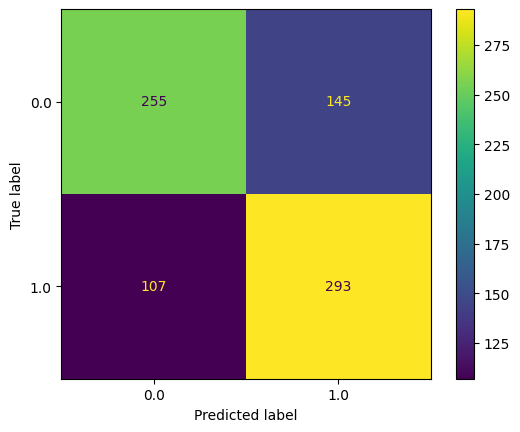

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = ( all_distances < best_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions( all_labels, predictions);

In [27]:
from sklearn.metrics import classification_report

print( classification_report( all_labels, predictions, target_names=[ "Different", "Same" ]))

              precision    recall  f1-score   support

   Different       0.70      0.64      0.67       400
        Same       0.67      0.73      0.70       400

    accuracy                           0.69       800
   macro avg       0.69      0.69      0.68       800
weighted avg       0.69      0.69      0.68       800



# few shot learning

In [28]:
print(len(test_path))
print(len(test_label))
print(np.unique(test_label))

3760
3760
[ 8  9 15 17 23 27]


In [29]:
print(test_path[:3])
print(test_label[:10])

['/home/ziba/.keras/datasets/images_background_extracted/images_background/Burmese_(Myanmar)/character09/0778_14.png'
 '/home/ziba/.keras/datasets/images_background_extracted/images_background/Burmese_(Myanmar)/character09/0778_07.png'
 '/home/ziba/.keras/datasets/images_background_extracted/images_background/Burmese_(Myanmar)/character09/0778_08.png']
[9 9 9 9 9 9 9 9 9 9]


In [30]:
def load_sngl_img(path):
    img , _=load_img(path , 0)
    return img

In [33]:
# تابع استخراج بردارهای ویژگی (امبدینگ) از تصاویر
def get_embeddings(paths):
    # لیست برای ذخیره تصاویر بارگذاری شده
    images = []
    
    # بارگذاری تک‌تک تصاویر از مسیرهای داده شده
    for path in paths:
        img = load_sngl_img(path)  # بارگذاری یک تصویر
        images.append(img)         # اضافه کردن به لیست

    # تبدیل لیست به تنسور برای پردازش دسته‌ای
    images = tf.stack(images)
    
    # استخراج امبدینگ با استفاده از encoder (حالت ارزیابی)
    embeddings = encoder(images, training=False)

    return embeddings


In [34]:
def few_shot_episode( test_path, test_label, encoder, n_way=3, k_shot=3, q_query=3):

    # 1. Select classes
    classes = np.unique(test_label)

    episode_classes = np.random.choice(classes,size=n_way,replace=False)
    print("Episode classes:", episode_classes)


    # =========================================================
    # 2. Create Support and Query sets
    support_paths = []
    support_labels = []

    query_paths = []
    query_labels = []

    for class_id in episode_classes:
        # All images belonging to this class
        class_indices = np.where(test_label == class_id)[0]

        # Select k_shot + q_query images
        selected_indices = np.random.choice(class_indices,size=k_shot + q_query,replace=False)

        # Split into Support and Query
        support_indices = selected_indices[:k_shot]
        query_indices = selected_indices[k_shot:]

        # Support
        for idx in support_indices:
            support_paths.append(test_path[idx])
            support_labels.append(class_id)

        # Query
        for idx in query_indices:
            query_paths.append( test_path[idx])
            query_labels.append( class_id )

    support_paths = np.array(support_paths)
    support_labels = np.array(support_labels)

    query_paths = np.array(query_paths)
    query_labels = np.array(query_labels)


    print("Support images:", len(support_paths))
    print("Query images:", len(query_paths))

    print("Support labels:", support_labels)
    print("Query labels:", query_labels)


    # 3. Extract Support Embeddings
    # =========================================================

    support_embeddings = get_embeddings(support_paths )
    print( "Support embedding shape:", support_embeddings.shape)

    # 4. Create Prototypes
    # =========================================================

    prototypes = []

    for class_id in episode_classes:
        class_mask = (support_labels == class_id)
        class_embeddings = support_embeddings[ class_mask]

        prototype = tf.reduce_mean(class_embeddings,axis=0 )
        prototypes.append(prototype)

    prototypes = tf.stack(prototypes)


    print( "Prototype shape:", prototypes.shape )

    # 5. Extract Query Embeddings
    # =========================================================
    query_embeddings = get_embeddings(query_paths)
    print( "Query embedding shape:", query_embeddings.shape )

    # 6. Calculate distances
    # =========================================================

    distances = tf.sqrt( tf.reduce_sum( tf.square( tf.expand_dims(query_embeddings, axis=1) - tf.expand_dims(prototypes, axis=0)),axis=2 ) + 1e-8)
    print("Distances shape:",distances.shape)

    # 7. Prediction
    # =========================================================

    predicted_indices = tf.argmin(distances,axis=1 )
    predicted_labels = np.array(episode_classes)[predicted_indices.numpy()]

    # 8. Accuracy
    # =========================================================

    accuracy = np.mean(predicted_labels == query_labels )
    print( f"Episode Accuracy: {accuracy:.2%}" )

    return accuracy

In [35]:
accuracy = few_shot_episode( test_path, test_label, encoder, n_way=3, k_shot=3, q_query=3)

print("Final accuracy:", accuracy)

Episode classes: [ 8 23 27]
Support images: 9
Query images: 9
Support labels: [ 8  8  8 23 23 23 27 27 27]
Query labels: [ 8  8  8 23 23 23 27 27 27]


W0000 00:00:1787918993.670545    4846 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1787918993.670598    4846 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 621.85MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Support embedding shape: (9, 256)
Prototype shape: (3, 256)
Query embedding shape: (9, 256)
Distances shape: (9, 3)
Episode Accuracy: 88.89%
Final accuracy: 0.8888888888888888
